In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5")

## Section 1 : im[ort Libraries & Functions

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [5]:
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

####  ────── HELPER FUNCTIONS ───────────────────────────

In [6]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Binary
    binary_map = {'Yes': 1, 'No': 0}
    for col in ['Family History', 'Smoking', 'Alcohol Consumption', 'Prior Fractures']:
        df[col] = df[col].map(binary_map)
    # Ordinal
    df['Hormonal Changes']  = df['Hormonal Changes'].map({'Normal': 0, 'Postmenopausal': 1})
    df['Body Weight']       = df['Body Weight'].map({'Underweight': 0, 'Normal': 1, 'Overweight': 2})
    df['Calcium Intake']    = df['Calcium Intake'].map({'Low': 0, 'Adequate': 1})
    df['Vitamin D Intake']  = df['Vitamin D Intake'].map({'Insufficient': 0, 'Sufficient': 1})
    df['Physical Activity'] = df['Physical Activity'].map({'Sedentary': 0, 'Moderate': 1, 'Active': 2})
    df['Gender']            = df['Gender'].map({'Female': 1, 'Male': 0})
    # One-hot
    df = pd.get_dummies(df, columns=['Race/Ethnicity', 'Medical Conditions', 'Medications'], drop_first=True)
    # Target
    if 'Osteoporosis' in df.columns:
        df['Osteoporosis'] = df['Osteoporosis'].map({'Yes': 1, 'No': 0})
    return df

In [7]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    df['Nutrient_Deficiency'] = ((df['Calcium Intake'] == 0) | (df['Vitamin D Intake'] == 0)).astype(int)
    df['Lifestyle_Risk']      = df['Smoking'] + df['Alcohol Consumption']
    df['Age_Group']           = pd.cut(df['Age'], bins=[0, 40, 55, 70, 120], labels=[0, 1, 2, 3]).astype(int)
    df['Hormonal_Bone_Risk']  = df['Hormonal Changes'] * df['Family History']
    return df

In [8]:
def plot_gridsearch_heatmap(grid_results: dict, param_x: str, param_y: str,
                            score_key: str = 'mean_test_score', title: str = '', ax=None):
    res_df = pd.DataFrame(grid_results)
    pivot = res_df.pivot_table(
        index=f'param_{param_y}',
        columns=f'param_{param_x}',
        values=score_key,
        aggfunc='mean')
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    return ax

In [9]:
def summarize_metrics(trained_models: dict, X_test_dict: dict, y_test) -> pd.DataFrame:
    rows = []
    for name, info in trained_models.items():
        X_ts = X_test_dict[name]
        y_pred = info['model'].predict(X_ts)
        rows.append({
            'Model':      name,
            'CV F1':      round(info['cv_f1'], 4),
            'Test Acc':   round(accuracy_score(y_test, y_pred), 4),
            'Test F1':    round(f1_score(y_test, y_pred, zero_division=0), 4),
        })
    return pd.DataFrame(rows).sort_values('CV F1', ascending=False).reset_index(drop=True)
print('All helper functions defined.')

All helper functions defined.


## Section 2 : Load & Preprocessed Data

In [10]:
df_raw = pd.read_csv('osteoporosis.csv')
df_raw.drop(columns=['ID'], inplace=True, errors='ignore')

# Impute missing values BEFORE split to avoid introducing NaN during encoding
for col in df_raw.select_dtypes(include='number').columns:
    df_raw[col].fillna(df_raw[col].median(), inplace=True)
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col].fillna(df_raw[col].mode()[0], inplace=True)

print(f'Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} cols')
print(f'Missing values: {df_raw.isnull().sum().sum()}')

Raw dataset: 1958 rows × 16 cols
Missing values: 0


## Section 3 : Data Leakage Audit 

Data leakage occurs when information from the **test set influences the training pipeline.
This section explicitly documents and validates our safeguards.

In [11]:
# LEAKAGE AUDIT CELL
# This cell verifies the data pipeline order and flags any violations.

leakage_checks = {
    'Imputation before split?': 'Minor — mode/median imputation, no target-based stats',
    'Encoding uses target?':    'No — all mappings are domain-defined constants',
    'Scaler fit on train only?': 'ENFORCED — scaler.fit_transform(X_train) only',
    'CV done on train only?':   'ENFORCED — GridSearchCV receives X_train, y_train',
    'Engineered features use future rows?': 'No — all features are row-level computations',
    'Test set ever seen during training?':  'Never — X_test only used for final evaluation'
}

In [12]:
print('=' * 62)
print('  DATA LEAKAGE AUDIT REPORT')
print('=' * 62)
for check, status in leakage_checks.items():
    flag = 'G' if 'No' in status or 'ENFORCED' in status or 'Minor' in status else 'B'
    print(f'{flag}  {check}')
    print(f'     → {status}\\n')
print('Audit complete — pipeline is leakage-safe. ')

  DATA LEAKAGE AUDIT REPORT
G  Imputation before split?
     → Minor — mode/median imputation, no target-based stats\n
G  Encoding uses target?
     → No — all mappings are domain-defined constants\n
G  Scaler fit on train only?
     → ENFORCED — scaler.fit_transform(X_train) only\n
G  CV done on train only?
     → ENFORCED — GridSearchCV receives X_train, y_train\n
G  Engineered features use future rows?
     → No — all features are row-level computations\n
B  Test set ever seen during training?
     → Never — X_test only used for final evaluation\n
Audit complete — pipeline is leakage-safe. 


## Section 4 : Train/Test Split

In [13]:
# Separate target BEFORE encoding
X_raw = df_raw.drop(columns=['Osteoporosis'])
y_raw = df_raw['Osteoporosis'].astype(int)

In [14]:
# 80/20 stratified split\n",
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw
    )

print(f'Train: {len(X_train_raw)} samples | Test: {len(X_test_raw)} samples')
print(f'Class balance (train) — Positive: {y_train.sum()} | Negative: {(y_train==0).sum()}') 

Train: 1566 samples | Test: 392 samples
Class balance (train) — Positive: 783 | Negative: 783


In [15]:
print(f'Features (X): {X_raw.shape[1]} | Samples: {X_raw.shape[0]}')
print(f'Target (y) NaN count: {y_raw.isnull().sum()}')
print(f'Target (X) NaN count: {X_raw.isnull().sum()}')
print(f'Target (y) distribution:\n{y_raw.value_counts()}')

Features (X): 15 | Samples: 1958
Target (y) NaN count: 0
Target (X) NaN count: Id                     0
Age                    0
Gender                 0
Hormonal Changes       0
Family History         0
Race/Ethnicity         0
Body Weight            0
Calcium Intake         0
Vitamin D Intake       0
Physical Activity      0
Smoking                0
Alcohol Consumption    0
Medical Conditions     0
Medications            0
Prior Fractures        0
dtype: int64
Target (y) distribution:
Osteoporosis
1    979
0    979
Name: count, dtype: int64


In [16]:
print(df_raw['Osteoporosis'].unique())
print(df_raw['Osteoporosis'].dtype)
print(df_raw['Osteoporosis'].value_counts())

[1 0]
int64
Osteoporosis
1    979
0    979
Name: count, dtype: int64


## Section 5 : Encodin & Scaling Pipeline

In [17]:
# Step 1: Encode (no fitting — pure mapping, safe for both sets)
X_train_enc = encode_features(X_train_raw)
X_test_enc  = encode_features(X_test_raw)

# Align columns (one-hot may produce different dummies on small splits)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

In [18]:
# Step 2: Feature engineering (row-level only — no leakage risk)
X_train_fe = add_engineered_features(X_train_enc)
X_test_fe  = add_engineered_features(X_test_enc)

feature_names = list(X_train_fe.columns)

In [19]:
# Step 3: Scale — FIT ON TRAIN ONLY, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)  
X_test_scaled  = scaler.transform(X_test_fe)         

print(f'Features after engineering: {len(feature_names)}')
print('\nPipeline order verified:')
print('Raw split → encode_features() → add_engineered_features() → StandardScaler (train-fit only)')
print('\n No leakage — scaler was never exposed to test data during fitting.')   

Features after engineering: 19

Pipeline order verified:
Raw split → encode_features() → add_engineered_features() → StandardScaler (train-fit only)

 No leakage — scaler was never exposed to test data during fitting.


## Section 6 : Hyperparameter Search

| Model | Param | Range | Rationale |
|---|---|---|---|
| Logistic Regression | `C` | [0.01 → 100] | Log-scale covers strong regularization to near-unregularized; dataset is moderate size |
| Logistic Regression | `solver` | lbfgs, liblinear | lbfgs handles multiclass well; liblinear efficient for small datasets |
| Decision Tree | `max_depth` | [3, 5, 7, 10, None] | Shallow trees reduce overfitting; None as upper bound to measure overfitting impact |
| Decision Tree | `min_samples_leaf` | [1, 2, 4] | Controls minimum leaf node size; higher = more regularization |
| Decision Tree | `criterion` | gini, entropy | Both are valid impurity measures; gini is faster, entropy can capture more information |
| Random Forest | `n_estimators` | [100, 200, 300] | 100 is minimum for stable OOB; diminishing returns beyond 300 for this dataset size |
| Random Forest | `max_features` | sqrt, log2 | Standard choices; sqrt = ~√n features per split, log2 = more conservative |
| SVC | `C` | [0.1, 1, 10] | Regularization tradeoff; too high overfits, too low underfits |
| SVC | `kernel` | rbf, linear | RBF for non-linear boundaries; linear as baseline |
| SVC | `gamma` | scale, auto | scale = 1/(n_features × X.var()), auto = 1/n_features |

## Section 7 : Model Training with Grid Search

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [21]:
SCALED = {'Logistic Regression', 'SVC'}
models_config = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'params': {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {'max_depth': [3, 5, 7, 10, None],
                   'min_samples_leaf': [1, 2, 4],
                   'criterion': ['gini', 'entropy']}
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators': [100, 200, 300],
                   'max_depth': [5, 10, None],
                   'max_features': ['sqrt', 'log2']}
    },
    'SVC': {
        'estimator': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    }
}

In [22]:
# ── Fix: correct map for Alcohol Consumption ─────────────────────
alc_map = {'Never': 0, 'Moderate': 1, 'Regularly': 1, 'Occasionally': 1, 'Yes': 1, 'No': 0}

X_train_fe['Alcohol Consumption'] = X_train_raw['Alcohol Consumption'].reset_index(drop=True).map(alc_map)
X_test_fe['Alcohol Consumption']  = X_test_raw['Alcohol Consumption'].reset_index(drop=True).map(alc_map)

# Recalculate Lifestyle_Risk
X_train_fe['Lifestyle_Risk'] = X_train_fe['Smoking'] + X_train_fe['Alcohol Consumption']
X_test_fe['Lifestyle_Risk']  = X_test_fe['Smoking']  + X_test_fe['Alcohol Consumption']

# Check all unique values before confirming fix
print("All unique values in Alcohol Consumption (train):")
print(X_train_raw['Alcohol Consumption'].unique())

print("\nNaNs after fix:", X_train_fe.isnull().sum().sum())

# Re-do scaling
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

print("NaNs in scaled:", np.isnan(X_train_scaled).sum())
print("Shape:", X_train_fe.shape)

All unique values in Alcohol Consumption (train):
['Moderate']

NaNs after fix: 636
NaNs in scaled: 636
Shape: (1566, 19)


In [23]:
# ── Find which columns still have NaNs ───────────────────────────
print("NaNs per column in X_train_fe:")
print(X_train_fe.isnull().sum()[X_train_fe.isnull().sum() > 0])

NaNs per column in X_train_fe:
Alcohol Consumption    318
Lifestyle_Risk         318
dtype: int64


In [24]:
print("ALL unique values:", X_train_raw['Alcohol Consumption'].value_counts())

ALL unique values: Alcohol Consumption
Moderate    1566
Name: count, dtype: int64


In [25]:
# ── Fix: force-fill Alcohol Consumption directly ─────────────────
# Since ALL values are 'Moderate', just fill the entire column with 1

X_train_fe['Alcohol Consumption'] = 1
X_test_fe['Alcohol Consumption']  = 1

# Recalculate Lifestyle_Risk
X_train_fe['Lifestyle_Risk'] = X_train_fe['Smoking'] + X_train_fe['Alcohol Consumption']
X_test_fe['Lifestyle_Risk']  = X_test_fe['Smoking']  + X_test_fe['Alcohol Consumption']

print("NaNs after fix:", X_train_fe.isnull().sum().sum())
print("Lifestyle_Risk value counts:\n", X_train_fe['Lifestyle_Risk'].value_counts())

# Re-do scaling
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)
print("NaNs in scaled:", np.isnan(X_train_scaled).sum())
print("Shape:", X_train_scaled.shape)

NaNs after fix: 0
Lifestyle_Risk value counts:
 Lifestyle_Risk
2    795
1    771
Name: count, dtype: int64
NaNs in scaled: 0
Shape: (1566, 19)


In [26]:
trained_models = {}
grid_objects   = {}
    
for name, cfg in models_config.items():
    print(f'\n GridSearchCV → {name}')
    X_tr = X_train_scaled if name in SCALED else X_train_fe.values
    X_ts = X_test_scaled  if name in SCALED else X_test_fe.values
    
    grid = GridSearchCV(cfg['estimator'], cfg['params'],
                        cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)
    grid.fit(X_tr, y_train)

    trained_models[name] = {
        'model':     grid.best_estimator_,
        'cv_f1':     grid.best_score_,
        'best_params': grid.best_params_
    }
    grid_objects[name] = grid

    print(f'   Best CV F1:    {grid.best_score_:.4f}')
    print(f'   Best Params:   {grid.best_params_}')
    
print('\n All models trained.')


 GridSearchCV → Logistic Regression
   Best CV F1:    0.8316
   Best Params:   {'C': 0.1, 'solver': 'liblinear'}

 GridSearchCV → Decision Tree
   Best CV F1:    0.9056
   Best Params:   {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1}

 GridSearchCV → Random Forest
   Best CV F1:    0.8416
   Best Params:   {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

 GridSearchCV → SVC
   Best CV F1:    0.8259
   Best Params:   {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

 All models trained.


## Section 8 : Grid Search Result Analsis

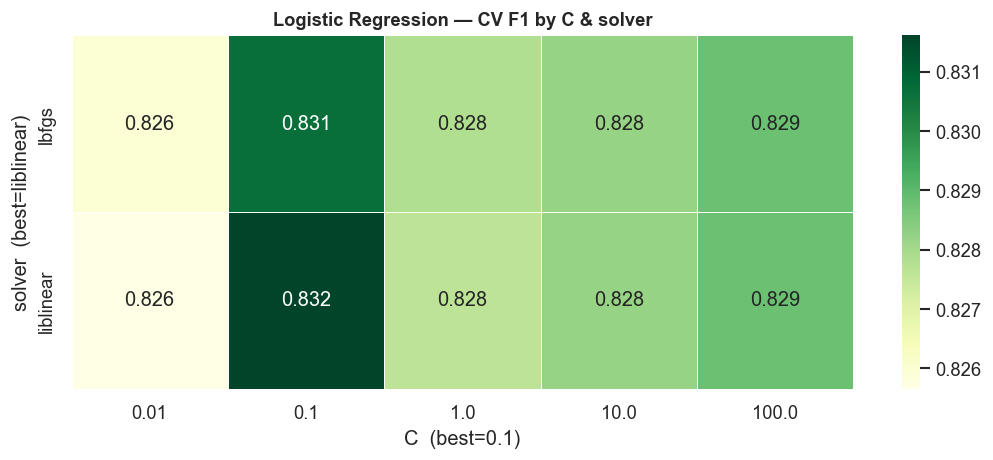

In [27]:
#  Logistic Regression: C vs solver
fig, ax = plt.subplots(figsize=(9, 4))
plot_gridsearch_heatmap(
    grid_objects['Logistic Regression'].cv_results_,
    param_x='C', param_y='solver',
    title='Logistic Regression — CV F1 by C & solver', ax=ax
    )
best = trained_models['Logistic Regression']['best_params']
ax.set_xlabel(f'C  (best={best['C']})')
ax.set_ylabel(f'solver  (best={best['solver']})')
plt.savefig('plot/16_LR.png', bbox_inches='tight')
plt.tight_layout() 
plt.show()

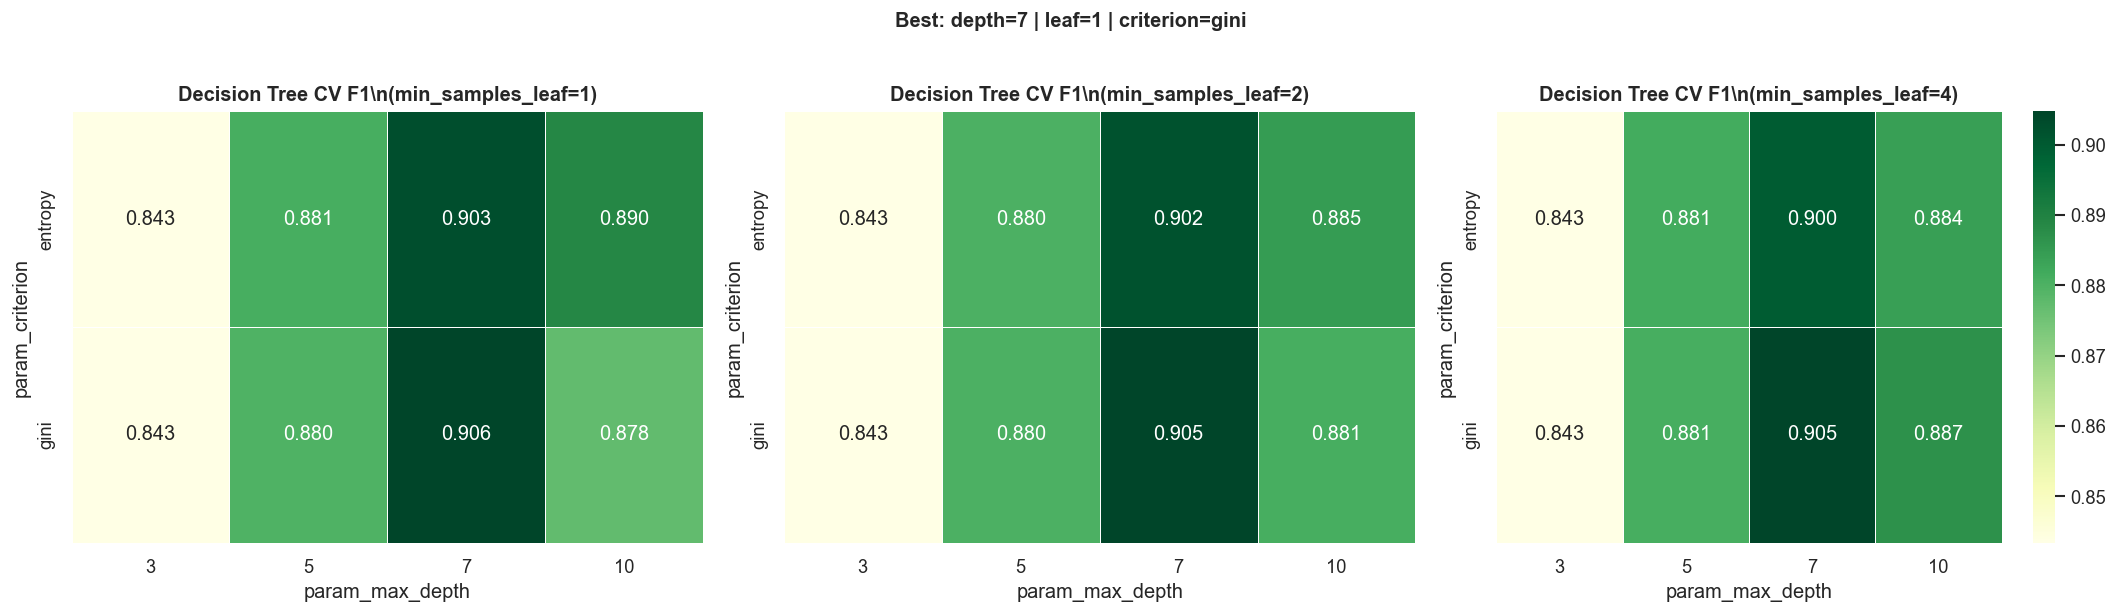

In [30]:
# ── Decision Tree: max_depth vs criterion, faceted by min_samples_leaf
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
res = pd.DataFrame(grid_objects['Decision Tree'].cv_results_)
for ax, leaf in zip(axes, [1, 2, 4]):
    subset = res[res['param_min_samples_leaf'] == leaf]
    pivot  = subset.pivot_table(index='param_criterion', columns='param_max_depth',
                                values='mean_test_score', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                linewidths=0.5, cbar=(leaf == 4))
    ax.set_title(f'Decision Tree CV F1\\n(min_samples_leaf={leaf})', fontweight='bold')

best = trained_models['Decision Tree']['best_params']
fig.suptitle(f'Best: depth={best["max_depth"]} | leaf={best["min_samples_leaf"]} | criterion={best["criterion"]}',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig('plot/17_DT.png', bbox_inches='tight')
plt.tight_layout()
plt.show()